# IFN680 Assessment 2 - Chest X-Ray Pneumonia Detection

## Convolutional Neural Networks
### Karan Rooprai - N12498122

## Loading and splitting The Data

In [1]:
import torchvision.transforms as transforms
import torchvision
import torch.nn as nn
import torch.optim as optim
import torch

import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

from tqdm import tqdm

torch.manual_seed(0)
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

transform = transforms.Compose(
    [transforms.Grayscale(),
     transforms.ToTensor(),
     transforms.Normalize((0.5), (0.5)),
    ])


trainval_dataset = torchvision.datasets.ImageFolder('chest_xray/trainval', transform = transform)
train_portion = 0.8
val_portion = 0.2

all_indexes = np.arange(len(trainval_dataset))
all_targets = trainval_dataset.targets

train_idx, val_idx = train_test_split(all_indexes, train_size=train_portion, stratify = all_targets, random_state = 0)

train_dataset = torch.utils.data.Subset(trainval_dataset, train_idx)
val_dataset = torch.utils.data.Subset(trainval_dataset, val_idx)

test_dataset = torchvision.datasets.ImageFolder('chest_xray/test', transform = transform)

batch_size = 8

trainloader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size,
                                          shuffle=True, num_workers = 2)
valloader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size,
                                          shuffle=False, num_workers = 2)
testloader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size,
                                          shuffle=False, num_workers = 2)


## Load the trained model

In [2]:
from model import load_vgg

vgg = load_vgg()
vgg.eval()
vgg.to(device)
print("Loaded trained VGG from vgg.pth")


Loaded trained VGG from vgg.pth


## Training and Validation Loss

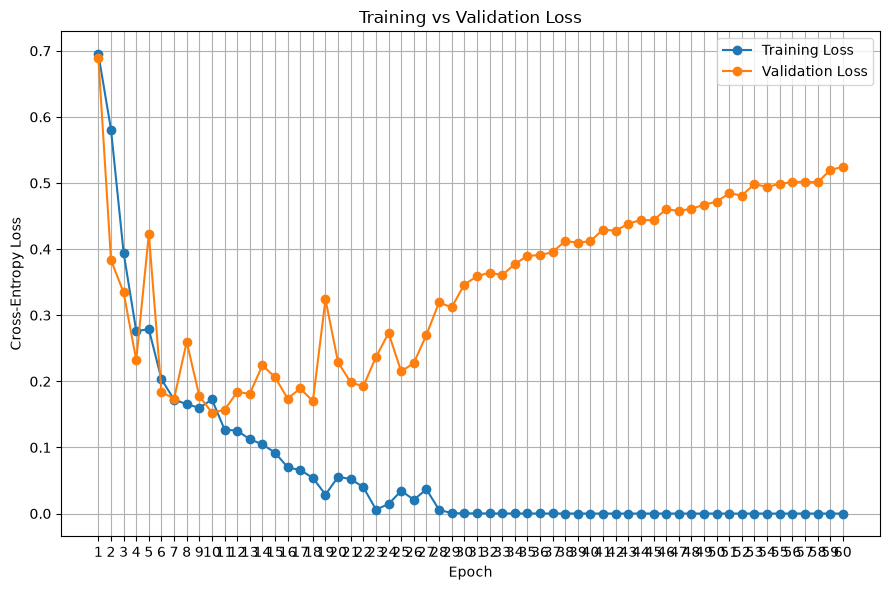

Final training loss:   0.0000051120
Final validation loss: 0.5246852977


In [3]:
history = torch.load('history.pth', weights_only=False)
train_loss = history['train_loss']
val_loss = history['val_loss']
epochs = range(1, len(train_loss) + 1)

plt.figure(figsize=(9, 6))
plt.plot(epochs, train_loss, marker='o', label='Training Loss')
plt.plot(epochs, val_loss, marker='o', label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.title('Training vs Validation Loss')

plt.xticks(list(epochs))

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig('Figure1_TrainVal_Loss.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'Final training loss:   {train_loss[-1]:.10f}')
print(f'Final validation loss: {val_loss[-1]:.10f}')


## Evaluation on test set

In [4]:
gt_test = []
test_pred = []
for data in tqdm(testloader, total=len(testloader)):
    with torch.no_grad():
        inputs, labels = data
        x = inputs.to(device)
        pred = vgg(x)
        predicted = torch.argmax(pred, axis=1)
        test_pred += predicted.cpu().tolist()
        gt_test += labels.cpu().tolist()

print(f'Evaluated {len(gt_test)} test images')


100%|██████████| 74/74 [00:00<00:00, 78.03it/s] 

Evaluated 588 test images


## Confusion Matrix

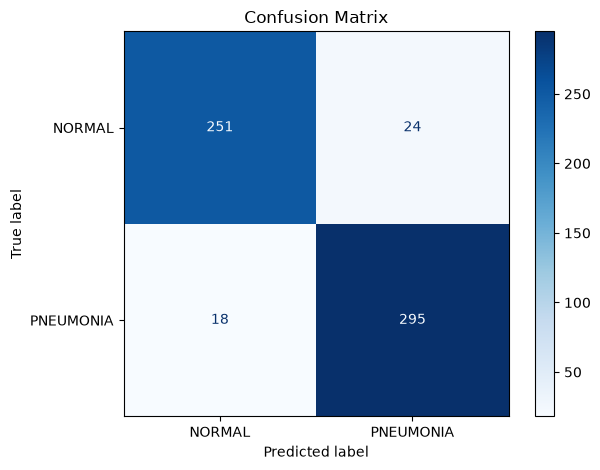

Confusion matrix
[[251  24]
 [ 18 295]]


In [5]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

disp = ConfusionMatrixDisplay.from_predictions(gt_test, test_pred,
                                               display_labels=test_dataset.classes,
                                               cmap='Blues')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig('Figure2_Confusion_Matrix.png', dpi=200, bbox_inches='tight')
plt.show()

cm = confusion_matrix(gt_test, test_pred)
print('Confusion matrix')
print(cm)


## Precision, Recall and Accuracy

In [6]:
from sklearn.metrics import classification_report, precision_recall_fscore_support, accuracy_score

print(classification_report(gt_test, test_pred, target_names=test_dataset.classes, digits=4))

precision, recall, f1, support = precision_recall_fscore_support(gt_test, test_pred)
accuracy = accuracy_score(gt_test, test_pred)

print(f'Overall accuracy: {accuracy:.4f}\n')
for i, name in enumerate(test_dataset.classes):
    print(f'{name:10s}  precision={precision[i]:.4f}  recall={recall[i]:.4f}')

              precision    recall  f1-score   support

      NORMAL     0.9331    0.9127    0.9228       275
   PNEUMONIA     0.9248    0.9425    0.9335       313

    accuracy                         0.9286       588
   macro avg     0.9289    0.9276    0.9282       588
weighted avg     0.9287    0.9286    0.9285       588

Overall accuracy: 0.9286

NORMAL      precision=0.9331  recall=0.9127
PNEUMONIA   precision=0.9248  recall=0.9425


## Confusion Matrix Breakdown

In [7]:
tn, fp, fn, tp = cm.ravel()

print(f'True Negatives  (Predicted Normal, and is Normal):                              {tn}')
print(f'False Positives (Predcited Pneumonia, and is Normal i.e wrongly flagged sick):  {fp}')
print(f'False Negatives (Predicted Normal, and is Pneumonia i.e missed):                {fn}')
print(f'True Positives  (Predicted Pneumonia, and is Pneumonia):                        {tp}')


True Negatives  (Predicted Normal, and is Normal):                              251
False Positives (Predcited Pneumonia, and is Normal i.e wrongly flagged sick):  24
False Negatives (Predicted Normal, and is Pneumonia i.e missed):                18
True Positives  (Predicted Pneumonia, and is Pneumonia):                        295
